In [2]:
#Monthly Job Postings for Top Data Jobs in the US
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [28]:
import seaborn as sns

In [50]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
df_US = df[(df['job_title_short'].isin(job_titles))&(df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset='salary_year_avg')
df_US_DA = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()


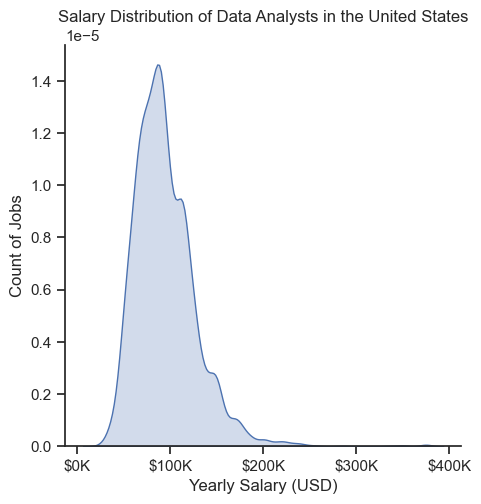

In [51]:
sns.set_theme(style='ticks')
sns.displot(data=df_US_DA['salary_year_avg'], kind='kde', fill=True)
#df_US_DA['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')
plt.title('Salary Distribution of Data Analysts in the United States')
plt.ylabel('Count of Jobs')
plt.xlabel('Yearly Salary (USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.show()

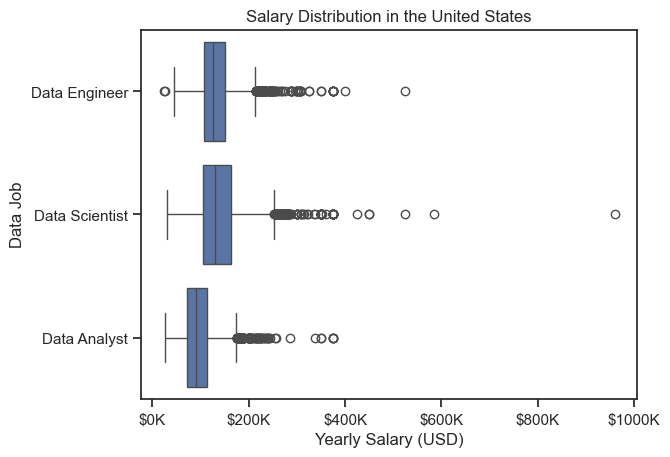

In [52]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
job_list = [df_US[df_US['job_title_short'] == job]['salary_year_avg'] for job in job_titles]
job_list


sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short', vert=False)
#plt.boxplot(data=job_list, x=job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.ylabel('Data Job')
plt.xlabel('Yearly Salary (USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.show()